In [ ]:
#This notebook is an example of how to reconstruct spectra. 
#The model is trained on DisCoTNO spectra, and applied on Neptune Trojan spectra.
#It generates samples in the PCA space, transforms them back to the original space, and visualizes the reconstructed spectra along with uncertainty intervals.

%matplotlib inline
import sys
import os
sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd
from nircam_filters import NIRCamFilters
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt
import matplotlib
from scipy import interpolate
from scipy.stats import norm
from PCA_classifier import TNOpcClassifier
from spectra_generator import PCASpectrumGenerator
import seaborn as sns
import pickle

In [2]:
# this function is used to calculate synthetic photometry from a spectrum
def calculate_photometry(spectrum, bands, uncertainty=0.2):
    """
    Calculate synthetic photometry from a spectrum.
    """
    wl = np.arange(0.75, 5.1, (5.1-0.75)/850) # wavelength range from 0.75 to 5.1 microns, with 850 points
    spec_phot = interpolate.interp1d(wl, spectrum)
    phots = []
    for band in bands:
        w_max, w_min = nirfilters.f_bandwidths[band]
        wls= np.linspace(w_min, w_max, num=100)
        phot = spec_phot(wls).mean() + uncertainty * (np.random.random() - 0.5)
        phots.append(phot)
        
    phots = np.array(phots)
    return phots

In [3]:
# this read NT spectra

def read_spec(file_name, color, name, wmin=0.75, wmax=5.1, w_nor = 2.5975, ls = '-', alpha=1, legend=False):
    df = pd.read_csv(file_name)
    df = df[(df.um>=0.7525) & (df.um<=4.9975)] 
    nor_ind = df.um == w_nor
    #print(nor_ind)
    ref = df.reflectance.values/df.reflectance[nor_ind].values
    #print(((um_down+um_up)/2))
    #plt.xlabel(r'Wavelength ($\mu$m)')
    #plt.ylabel('Relative Reflenctance')
    #print((um_down+um_up)/2)
    #if legend:
    #    plt.plot(df.um, ref, c=color, label=name, alpha=alpha, ls = ls)
    #    plt.legend(bbox_to_anchor=(1.0, 1.))
    #else:
    #    plt.plot(df.um, df.reflectance, c=color, alpha=alpha, ls = ls)
    return ref, df.uncertainty, df.um  #np.array([r for r in ref if not math.isnan(r)])

In [17]:
# load NT spectra for validation
NTs = ['2010 TS191.csv', '2011 WG157.csv', '2013 VX30.csv']
NTs = [f'../data/spectra/{nt}' for nt in NTs]
nt_specs = []
for nt in NTs:
    spec, spec_err, um = read_spec(nt, 'r', nt.split('.')[0])
    nt_specs.append(spec)


In [7]:
# load spectra manifold. This manifold here has dimensions = 9 
with open("../data/processed/manifold.pkl", "rb") as file:
    manifold = pickle.load(file)

In [8]:
# load filters
nirfilters = NIRCamFilters()
nirfilters.fnames

dict_keys(['F070W', 'F090W', 'F115W', 'F150W', 'F200W', 'F277W', 'F356W', 'F444W', 'F140M', 'F162M', 'F182M', 'F210M', 'F250M', 'F300M', 'F335M', 'F360M', 'F410M', 'F430M', 'F460M', 'F480M', 'F150W2', 'F322W2'])

In [9]:
#select band sets for reconstruction
band_sets = []

#band_sets.append(['F090W', 'F115W', 'F210M', 'F250M', 'F300M', 'F360M'])
band_sets.append(['F090W', 'F115W', 'F150W', 'F360M', 'F410M', 'F460M'])
#band_sets.append(['F090W', 'F115W', 'F150W', 'F250M', 'F300M', 'F335M'])
#band_sets.append(['F090W', 'F115W', 'F356W', 'F444W'])
#band_sets.append(['F090W', 'F115W', 'F300M', 'F335M'])
#band_sets.append(['F090W', 'F115W', 'F300M', 'F360M'])
#band_sets.append(['F182M', 'F210M', 'F300M', 'F335M'])
#band_sets.append(['F150W2', 'F322W2'])
#band_sets.append(['F090W', 'F356W'])
#band_sets.append(['F090W', 'F360M'])
#band_sets.append(['F090W', 'F335M'])
#band_sets.append(['F090W', 'F115W', 'F410M', 'F460M'])    


print(f"Band set: {band_sets[0]}")

Band set: ['F090W', 'F115W', 'F150W', 'F360M', 'F410M', 'F460M']


['F090W', 'F115W', 'F150W', 'F360M', 'F410M', 'F460M']


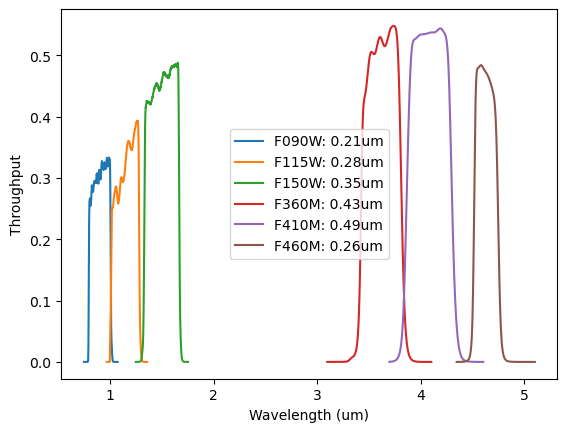

In [10]:
#show the filter transmission curves for the selected band set
band_set = band_sets[0]
#band_set = ['F090W', 'F115W', 'F300M', 'F360M']
print(band_set)
nirfilters.plot_filters_set(band_set)
plt.xlabel('Wavelength (um)')
plt.ylabel('Throughput')
plt.legend()
plt.show()

In [11]:
#generate training data and train model

def generate_data(n_samples=1000, bands = ['F115W', 'F200W', 'F277W', 'F356W', 'F444W'], uncertainty = 0.2, spectra_pool= None, labels_pool=None):
    X = []
    Y = []
    labels = []
    nirfilters = NIRCamFilters()
    for i in range(n_samples):
        #generate photometry from the spectrum
        wl = np.arange(0.75, 5.1, (5.1-0.75)/850)
        rand_ind = np.random.randint(0, spectra_pool.shape[0])
        ref_spec = spectra_pool[rand_ind]

        if labels_pool is not None:
            label = labels_pool[rand_ind]
            labels.append(label)

        if ref_spec.shape[0] != 850:
            ref_spec = ref_spec[1:851]
            #raise ValueError("Spectrum length mismatch.")
        #print(ref_spec.shape)
        spec_phot = interpolate.interp1d(wl, ref_spec)
        phots = []
        for band in bands:
            w_max, w_min = nirfilters.f_bandwidths[band]
            c = nirfilters.f_bandcenters[band]
            wls= np.linspace(w_min, w_max, num=100)
            phot = spec_phot(wls).mean() + uncertainty * (np.random.random() - 0.5)
            phots.append(phot)
        
        phots = np.array(phots)
        X.append(phots)
        Y.append(ref_spec)
        
    return X, Y, labels

def reconstructor(PCA, band_set, spectra, model_name, n_components, training=False, interval=False):
    # --- 1. Generate Data ---
    X_train, Y_train_raw, labels = generate_data(20000, bands=band_set, spectra_pool= spectra) # Training set
    X_train = np.array(X_train)

    # --- 2. Dimensionality Reduction (PCA) ---
    # We cannot predict 100 columns efficiently.
    # We compress 100 bins -> 5 Principal Components.
    # These 5 numbers capture ~99% of the spectral shape.

    pca = PCA

    Y_train_pca = pca.transform(Y_train_raw) # Shape: (2000, 5)

    # --- 3. Prepare Data for AutoGluon ---
    # AutoGluon expects a DataFrame.
    # Inputs: Mag_0, Mag_1...
    # Targets: PC_0, PC_1...

    feature_cols = [f'mag_{i}' for i in range(X_train.shape[1])]
    target_cols = [f'pc_{i}' for i in range(n_components)]

    # Create Training DataFrame
    train_df = pd.DataFrame(X_train, columns=feature_cols)
    # Add targets (PC1, PC2, etc.)
    for i in range(n_components):
        train_df[target_cols[i]] = Y_train_pca[:, i]

    if training:
        # --- 4. Train AutoGluon with Transformer ---
        # Since AutoGluon is single-target, we train one predictor per PC component.

        predictors = {}
        model_save_path = f"{model_name}"

        nn_hyperparameters = {
            'GBM': {} # Gradient Boosting (standard tree model)
        }
        

        dense_quantiles = np.arange(0.01, 0.99, 0.01).tolist()
        #print("\n--- Starting AutoML Training (Transformer Enabled) ---")
        print("\n--- Starting AutoML Training ---")
        for i, target in enumerate(target_cols):
            print(f"Training model for Component {target}...")
            
            # We drop other targets so the model doesn't cheat by using PC_0 to predict PC_1
            train_data_specific = train_df.drop(columns=[t for t in target_cols if t != target])
            
            if interval:
                predictor = TabularPredictor(label=target, problem_type='quantile', quantile_levels=dense_quantiles, path=f"{model_save_path}/{target}", verbosity=0)
            else:
                predictor = TabularPredictor(label=target, problem_type='regression', path=f"{model_save_path}/{target}", verbosity=0)
            
            # Passing hyperparameters activates the specific models we want
            predictor.fit(
                train_data_specific, 
                hyperparameters=nn_hyperparameters,
                time_limit=60 
            )
        
            predictors[target] = predictor
    else:
        predictors = {}
        model_save_path = f"{model_name}"
        for i, target in enumerate(target_cols):
            predictor = TabularPredictor.load(f"{model_save_path}/{target}")
            predictors[target] = predictor

    return predictors


In [12]:
# train predictor for the selected band set
n_components = 9 #
font = {'size'   : 12}
matplotlib.rc('font', **font)

recon_model_name = f"../models/9PCs/model_F090W_F115W_F150W_F360M_F410M_F460M_9pcs/"
interval = True # whether to train quantile regression model for uncertainty estimation
manifold = manifold
classifier_model= f'../models/classifier_models/ag-20260306_204013'
spectra = manifold.generate(n_samples=20000)
classifier = TNOpcClassifier(manifold.pca, model_save_path=classifier_model)

#load pre-trained classifier for TNO classification, which is used to predict the class of the input spectrum
classifier.predictor = TabularPredictor.load(classifier_model)  

#set training = True to train the model, False to load the model from disk
# It takes about 1 minute to train one model for each PC component, so 9 minutes for 9 components.
# Training with interval=False takes about seconds per component, however, will not generate uncertainty intervals for the reconstructed spectra.
predictors = reconstructor(manifold.pca, band_set, spectra, recon_model_name, n_components=n_components, training = True, interval=interval) 



--- Starting AutoML Training ---
Training model for Component pc_0...
Training model for Component pc_1...
Training model for Component pc_2...
Training model for Component pc_3...
Training model for Component pc_4...
Training model for Component pc_5...
Training model for Component pc_6...
Training model for Component pc_7...
Training model for Component pc_8...


In [13]:
predictors

{'pc_0': <autogluon.tabular.predictor.predictor.TabularPredictor at 0x1086cd110>,
 'pc_1': <autogluon.tabular.predictor.predictor.TabularPredictor at 0x30fdce050>,
 'pc_2': <autogluon.tabular.predictor.predictor.TabularPredictor at 0x17271e290>,
 'pc_3': <autogluon.tabular.predictor.predictor.TabularPredictor at 0x30e543a90>,
 'pc_4': <autogluon.tabular.predictor.predictor.TabularPredictor at 0x30e9d9d10>,
 'pc_5': <autogluon.tabular.predictor.predictor.TabularPredictor at 0x30e5806d0>,
 'pc_6': <autogluon.tabular.predictor.predictor.TabularPredictor at 0x30ed33990>,
 'pc_7': <autogluon.tabular.predictor.predictor.TabularPredictor at 0x172cfdc90>,
 'pc_8': <autogluon.tabular.predictor.predictor.TabularPredictor at 0x172e8ea90>}

In [14]:
#load pre-trained classifier for TNO classification, which is used to predict the class of the input spectrum
classifier_model= f'../models/classifier_models/ag-20260306_204013'
classifier = TNOpcClassifier(manifold.pca, model_save_path=classifier_model)
classifier.predictor = TabularPredictor.load(classifier_model)  

In [15]:
# This function generates physically scaled, correlated Monte Carlo samples for a new prediction. 


def generate_nd_samples(new_quantiles, quantile_levels, correlation_matrix, num_samples=1000):
    """
    Generates physically scaled, correlated Monte Carlo samples for a new prediction.
    
    Parameters:
    - new_quantiles: A list of 5 arrays. Each array contains the predicted 
                     quantile values for the new object from one AutoGluon model.
    - quantile_levels: The array of probabilities used during training (e.g., 0.01 to 0.99).
    - correlation_matrix: The nxn global correlation matrix calculated from validation residuals.
    - num_samples: How many 5D samples to generate.
    
    Returns:
    - A (num_samples, 5) NumPy array of correlated physical values.
    """
    num_dims = len(new_quantiles)
    
    # 1. The Geometry: Draw from standard normal distribution (variance normalized to 1)
    # The means are 0, and the covariance is strictly your correlation matrix.
    mv_normal_samples = np.random.multivariate_normal(
        mean=np.zeros(num_dims), 
        cov=correlation_matrix, 
        size=num_samples
    )
    
    # 2. The Bridge: Convert the normal samples to uniform probabilities [0, 1]
    correlated_uniforms = norm.cdf(mv_normal_samples)
    
    # 3. The Scale: Map back to the physical bounds using the independent AutoGluon models
    final_samples = np.zeros((num_samples, num_dims))
    
    for dim in range(num_dims):
        inverse_cdf = interpolate.interp1d(
            x=quantile_levels, 
            y=new_quantiles[dim], 
            kind='linear', 
            bounds_error=False,
            # If a sample falls slightly outside the defined quantiles, clamp it to the edge
            fill_value=(new_quantiles[dim][0], new_quantiles[dim][-1]) 
        )
        
        # Stretch the uniform probabilities [0, 1] into the physical target units
        final_samples[:, dim] = inverse_cdf(correlated_uniforms[:, dim])
        
    return final_samples

In [18]:
feature_cols = [f'mag_{i}' for i in range(len(band_set))]
nt_phots = [calculate_photometry(nt_specs[i], band_set, uncertainty=0.2) for i in range(len(nt_specs))]
nt_df = pd.DataFrame(nt_phots, columns=feature_cols)

correlation_matrix = np.load('../data/processed/correlation_matrix_9d.npy') #the global correlation matrix pre-calculated from validation residuals

coverage : 0.9223529411764706


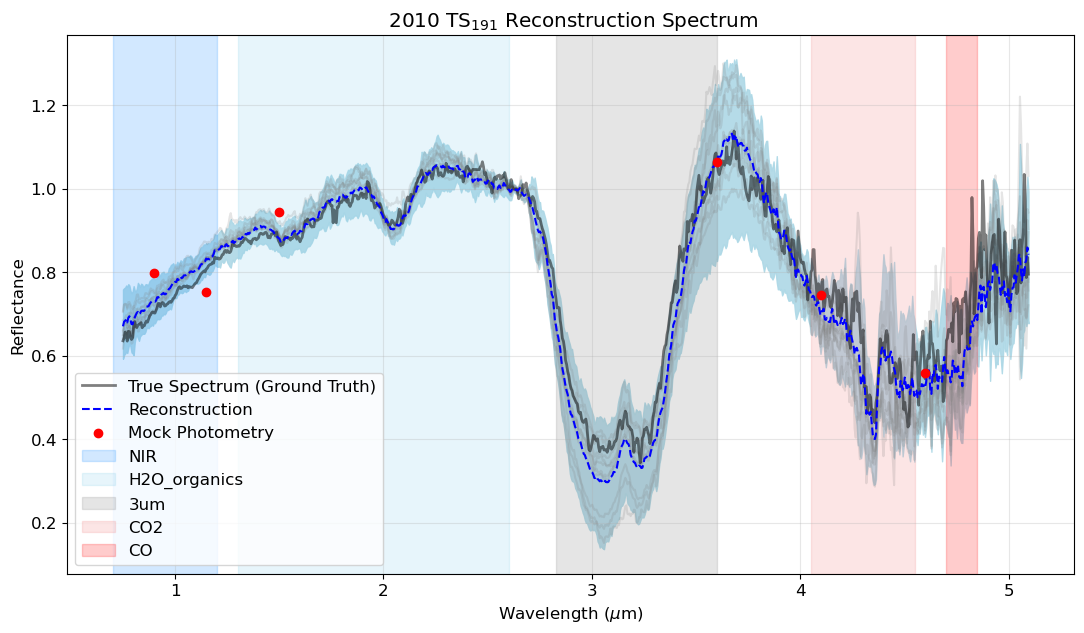

predicted_class
H2O         0.999
methanol    0.001
Name: count, dtype: float64

In [23]:
obj = 0
preds = []
target_cols = [f'pc_{i}' for i in range(n_components)]  
for j, target in enumerate(target_cols):
        preds.append(predictors[target].predict(nt_df).iloc[obj].values)

samples_nd = generate_nd_samples(
    new_quantiles= preds,
    quantile_levels=np.arange(0.01, 0.99, 0.01),
    correlation_matrix=correlation_matrix,
    num_samples=1000
)
wl = np.arange(0.75, 5.1, (5.1-0.75)/850) # wavelength range from 0.75 to 5.1 microns, with 850 points
spec_with_err = manifold.pca.inverse_transform(samples_nd)
lower = np.percentile(spec_with_err, 2.28, axis=0)
upper = np.percentile(spec_with_err, 97.72, axis=0)
reconstructed_spectra = np.mean(spec_with_err, axis=0)

bands = nirfilters.bandcenters_set(band_set)
grand_true = nt_specs[obj]
reconstructed_spectra_low = lower
reconstructed_spectra_high = upper
phots = nt_phots[obj]

# here calculates the coverage of the true spectrum by the uncertainty interval.
coverage = (grand_true >= lower) & (grand_true <= upper)
print("coverage :", coverage.sum() / len(grand_true))

plt.figure(figsize=(13, 7))
plt.title(r" 2010 TS$_{191}$ Reconstruction Spectrum")
for i in range(10):
    plt.plot(wl, spec_with_err[np.random.randint(0, 999)], alpha=0.2, color='grey')
plt.plot(wl, grand_true, label='True Spectrum (Ground Truth)', color='black', linewidth=2, alpha=0.5)
plt.plot(wl, reconstructed_spectra , label='Reconstruction', color='blue', linestyle='--')
plt.fill_between(wl, reconstructed_spectra_low, reconstructed_spectra_high, color='lightblue', alpha=0.9)
#plt.fill_between(wl, reconstructed_spectra_high , label='Reconstruction (95th percentile)', color='lightcoral', linestyle='--')


plt.scatter(bands, phots, label='Mock Photometry', color='red', zorder=5)
plt.axvspan(0.7, 1.2, color='dodgerblue', alpha=0.2, label='NIR')
plt.axvspan(1.3, 2.6, color='skyblue', alpha=0.2, label='H2O_organics')
#plt.axvspan(2.72, 2.77, color='lightsteelblue', alpha=0.2, label='CO2')
plt.axvspan(2.83, 3.6, color='grey', alpha=0.2, label='3um')
plt.axvspan(4.05, 4.55, color='lightcoral', alpha=0.2, label='CO2')
plt.axvspan(4.7, 4.85, color='red', alpha=0.2, label='CO')
#plt.title("AutoGluon (Gradient Boosting) + PCA Reconstruction")
plt.xlabel(r"Wavelength ($\mu$m)")
plt.ylabel("Reflectance")
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig("so277_4bands.pdf", dpi=300, bbox_inches='tight', pad_inches = 0)
plt.show()

# this classifies the 1000 realizations using the pre-trained TNO classifier
taxonomy = classifier.classify_reconstruction(samples_nd)
taxonomy.predicted_class.value_counts()/1000 # show the percentage of each class in the 1000 realizations

coverage : 0.8117647058823529


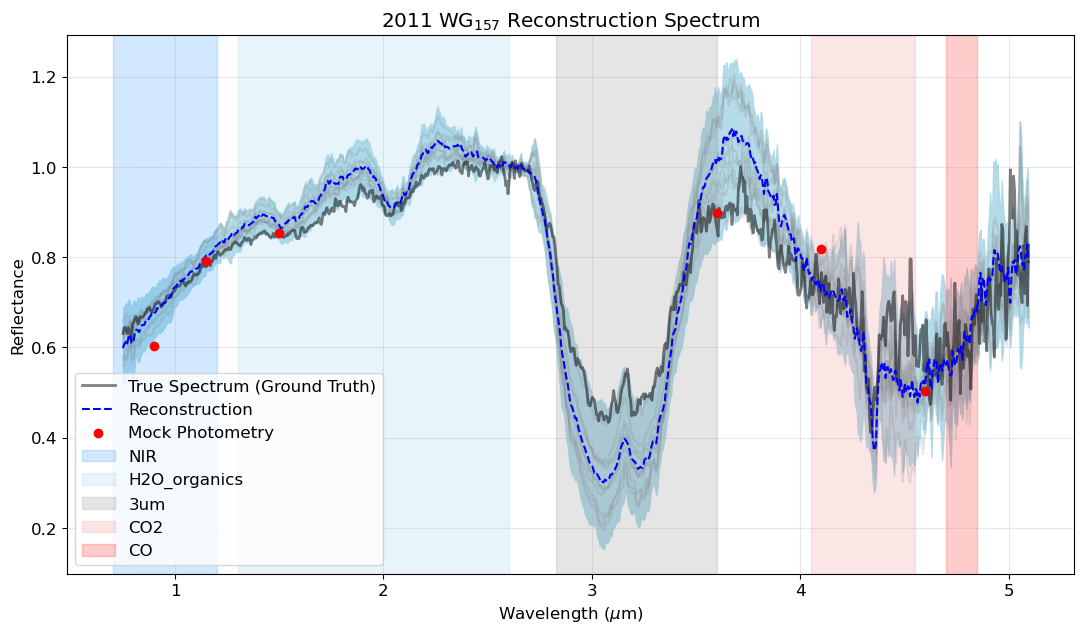

predicted_class
H2O         0.998
methanol    0.002
Name: count, dtype: float64

In [21]:
obj = 1

preds = []
for j, target in enumerate(target_cols):
        preds.append(predictors[target].predict(nt_df).iloc[obj].values)

samples_nd = generate_nd_samples(
    new_quantiles= preds,
    quantile_levels=np.arange(0.01, 0.99, 0.01),
    correlation_matrix=correlation_matrix,
    num_samples=1000
)

spec_with_err = manifold.pca.inverse_transform(samples_nd)
lower = np.percentile(spec_with_err, 2.28, axis=0)
upper = np.percentile(spec_with_err, 97.72, axis=0)
reconstructed_spectra = np.mean(spec_with_err, axis=0)

bands = nirfilters.bandcenters_set(band_set)
grand_true = nt_specs[obj]
reconstructed_spectra_low = lower
reconstructed_spectra_high = upper
phots = nt_phots[obj]


coverage = (grand_true >= lower) & (grand_true <= upper)
print("coverage :", coverage.sum() / len(grand_true))

plt.figure(figsize=(13, 7))
plt.title(r"2011 WG$_{157}$ Reconstruction Spectrum")
for i in range(10):
    plt.plot(wl, spec_with_err[np.random.randint(0, 999)], alpha=0.2, color='grey')
plt.plot(wl, grand_true, label='True Spectrum (Ground Truth)', color='black', linewidth=2, alpha=0.5)
plt.plot(wl, reconstructed_spectra , label='Reconstruction', color='blue', linestyle='--')
plt.fill_between(wl, reconstructed_spectra_low, reconstructed_spectra_high, color='lightblue', alpha=0.9)
#plt.fill_between(wl, reconstructed_spectra_high , label='Reconstruction (95th percentile)', color='lightcoral', linestyle='--')

plt.scatter(bands, phots, label='Mock Photometry', color='red', zorder=5)
plt.axvspan(0.7, 1.2, color='dodgerblue', alpha=0.2, label='NIR')
plt.axvspan(1.3, 2.6, color='skyblue', alpha=0.2, label='H2O_organics')
#plt.axvspan(2.72, 2.77, color='lightsteelblue', alpha=0.2, label='CO2')
plt.axvspan(2.83, 3.6, color='grey', alpha=0.2, label='3um')
plt.axvspan(4.05, 4.55, color='lightcoral', alpha=0.2, label='CO2')
plt.axvspan(4.7, 4.85, color='red', alpha=0.2, label='CO')
#plt.title("AutoGluon (Gradient Boosting) + PCA Reconstruction")
plt.xlabel(r"Wavelength ($\mu$m)")
plt.ylabel("Reflectance")
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig("rj103_4bands.pdf", dpi=300, bbox_inches='tight', pad_inches = 0)
plt.show()

taxonomy = classifier.classify_reconstruction(samples_nd)
taxonomy.predicted_class.value_counts()/1000 # division by 1000 to get the percentage

coverage : 0.7823529411764706


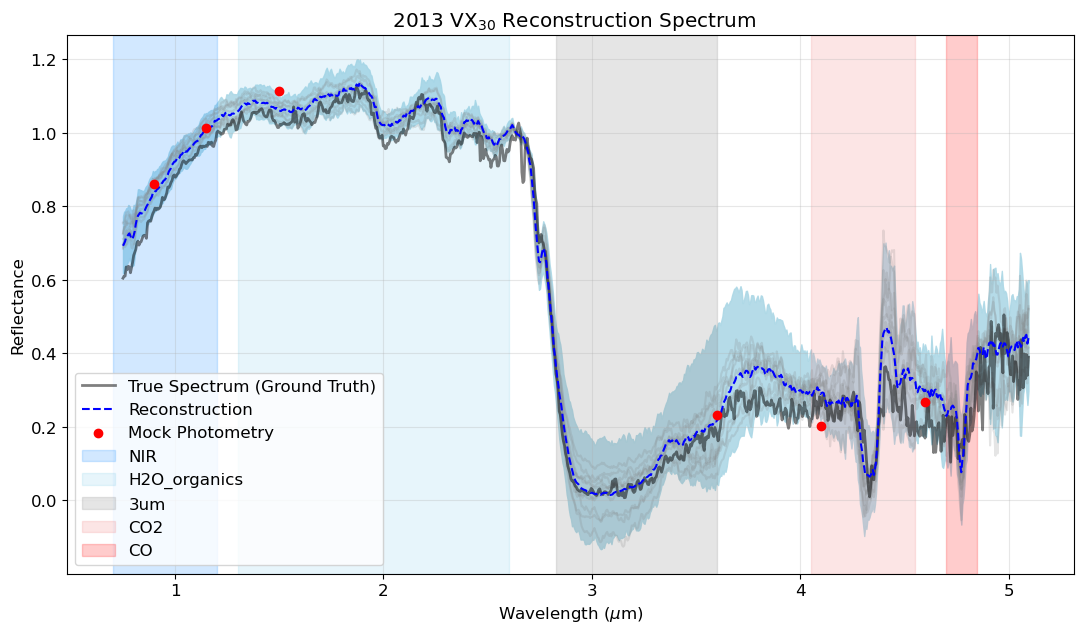

predicted_class
methanol    0.942
organic     0.036
H2O         0.020
CO2         0.002
Name: count, dtype: float64

In [22]:
obj = 2

preds = []
for j, target in enumerate(target_cols):
        preds.append(predictors[target].predict(nt_df).iloc[obj].values)

samples_nd = generate_nd_samples(
    new_quantiles= preds,
    quantile_levels=np.arange(0.01, 0.99, 0.01),
    correlation_matrix=correlation_matrix,
    num_samples=1000
)

spec_with_err = manifold.pca.inverse_transform(samples_nd)
lower = np.percentile(spec_with_err, 2.28, axis=0)
upper = np.percentile(spec_with_err, 97.72, axis=0)
reconstructed_spectra = np.mean(spec_with_err, axis=0)

bands = nirfilters.bandcenters_set(band_set)
grand_true = nt_specs[obj]
reconstructed_spectra_low = lower
reconstructed_spectra_high = upper
phots = nt_phots[obj]

coverage = (grand_true >= lower) & (grand_true <= upper)
print("coverage :", coverage.sum() / len(grand_true))

plt.figure(figsize=(13, 7))
plt.title(r" 2013 VX$_{30}$ Reconstruction Spectrum")
for i in range(10):
    plt.plot(wl, spec_with_err[np.random.randint(0, 999)], alpha=0.2, color='grey')
plt.plot(wl, grand_true, label='True Spectrum (Ground Truth)', color='black', linewidth=2, alpha=0.5)
plt.plot(wl, reconstructed_spectra , label='Reconstruction', color='blue', linestyle='--')
plt.fill_between(wl, reconstructed_spectra_low, reconstructed_spectra_high, color='lightblue', alpha=0.9)
#plt.fill_between(wl, reconstructed_spectra_high , label='Reconstruction (95th percentile)', color='lightcoral', linestyle='--')

plt.scatter(bands, phots, label='Mock Photometry', color='red', zorder=5)
plt.axvspan(0.7, 1.2, color='dodgerblue', alpha=0.2, label='NIR')
plt.axvspan(1.3, 2.6, color='skyblue', alpha=0.2, label='H2O_organics')
#plt.axvspan(2.72, 2.77, color='lightsteelblue', alpha=0.2, label='CO2')
plt.axvspan(2.83, 3.6, color='grey', alpha=0.2, label='3um')
plt.axvspan(4.05, 4.55, color='lightcoral', alpha=0.2, label='CO2')
plt.axvspan(4.7, 4.85, color='red', alpha=0.2, label='CO')
#plt.title("AutoGluon (Gradient Boosting) + PCA Reconstruction")
plt.xlabel(r"Wavelength ($\mu$m)")
plt.ylabel("Reflectance")
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig("spectrum_reconstruction_methanol.pdf", dpi=300, bbox_inches='tight', pad_inches = 0)
plt.show()

taxonomy = classifier.classify_reconstruction(samples_nd)
taxonomy.predicted_class.value_counts()/1000